---
## 1.SETUP INICIAL

### 1.1 Librerías

In [2]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import random
from PIL import Image
from tqdm.notebook import tqdm

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.cluster import KMeans, DBSCAN
from sklearn.model_selection import ParameterGrid, cross_val_score, train_test_split, learning_curve
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, roc_curve, auc, silhouette_score
    )

from sklearn.metrics.pairwise import euclidean_distances 
from sklearn.multiclass import OneVsRestClassifier

---
## 2.CARGA Y EXPLORACIÓN DE DATOS

### 2.1 Obtener datos

In [3]:
# Generar datos solo si no existen
from LHC import experiment_CMS

if not os.path.exists("CERN_dataset.zip") and not os.path.exists("CERN_datos"):
    print("Generando dataset CERN...")
    experiment_CMS(num_img=10000, size=64, zip_name="CERN_dataset")
    print("Dataset generado exitosamente.")
else:
    print("Dataset ya existe. Saltando generación.")

Generando dataset CERN...


KeyboardInterrupt: 

### 2.2 Cargar datos

In [7]:
def cargar_datos(zip_path="CERN_dataset.zip", carpeta_salida="CERN_datos", num_por_carpeta=1000):
    #1. Proceso para descomprimir el archivo ZIP
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(carpeta_salida)
    X = []
    y = []
    #2. Recorrer las carpetas con las imagenes
    for clase in os.listdir(carpeta_salida):
        clase_path = os.path.join(carpeta_salida, clase)
        if os.path.isdir(clase_path):
            img_names = os.listdir(clase_path)
            if num_por_carpeta is not None:
                img_names = img_names[:num_por_carpeta]
            for img_name in tqdm(img_names, desc=f"Cargando {clase}"):
                img_path = os.path.join(clase_path, img_name)

                # 3. Procedimiento para cargar imagenes en escala de grises
                img = Image.open(img_path).convert("L")
                X.append(np.array(img))
                y.append(clase)  # etiqueta = nombre de la carpeta

    X = np.array(X)
    return X, y

X, y = cargar_datos("CERN_dataset.zip", num_por_carpeta=1000)  
print(f"Se cargaron {len(X)} imágenes.")
print(f"Clases encontradas: {set(y)}")
print("Dimensiones de las imágenes:", X.shape)

Cargando electron:   0%|          | 0/1000 [00:00<?, ?it/s]

Cargando muon:   0%|          | 0/1000 [00:00<?, ?it/s]

Cargando neutrino:   0%|          | 0/1000 [00:00<?, ?it/s]

Cargando proton:   0%|          | 0/1000 [00:00<?, ?it/s]

Cargando quark:   0%|          | 0/1000 [00:00<?, ?it/s]

Cargando tau:   0%|          | 0/1000 [00:00<?, ?it/s]

Se cargaron 6000 imágenes.
Clases encontradas: {'electron', 'proton', 'tau', 'neutrino', 'quark', 'muon'}
Dimensiones de las imágenes: (6000, 64, 64)


### 2.3 Exploración visual

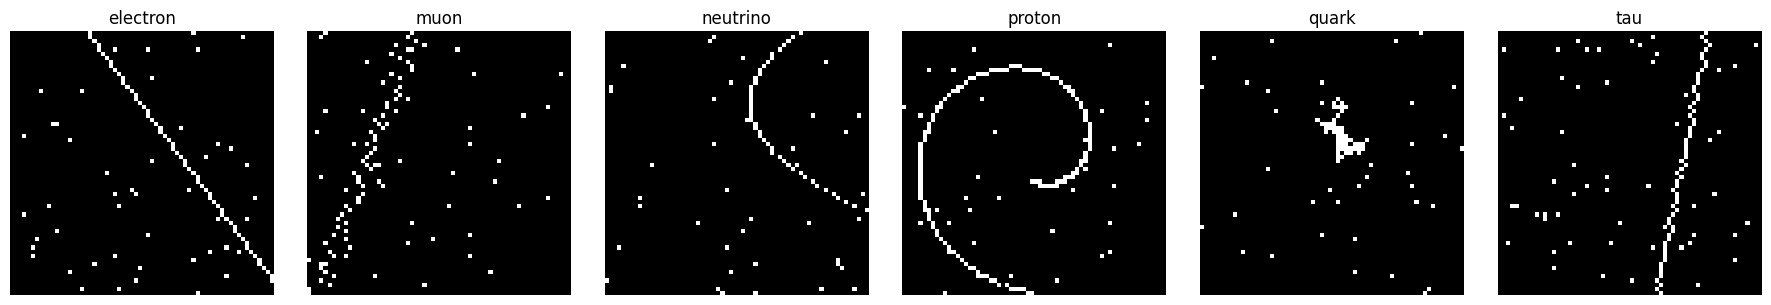

In [8]:
# Mostrar una imagen de cada clase
clases = sorted(list(set(y)))
fig, axs = plt.subplots(1, len(clases), figsize=(3*len(clases), 3))
for i, clase in enumerate(clases):
    idxs = [j for j, label in enumerate(y) if label == clase]
    idx = random.choice(idxs)  # índice aleatorio de la clase
    axs[i].imshow(X[idx], cmap='gray')
    axs[i].set_title(clase)
    axs[i].axis('off')
plt.tight_layout()
plt.show()

---
## 3. PREPROCESAMIENTO

### 3.1 Aplanar imágenes

In [9]:
print('Shape original:', X.shape)
X_flat = X.reshape(X.shape[0], -1)
print('Shape aplanado:', X_flat.shape)

Shape original: (6000, 64, 64)
Shape aplanado: (6000, 4096)


### 3.2 División Train/Test

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X_flat, y, test_size=0.2, random_state=42, stratify=y)

### 3.3 Escalado (StandardScaler)

In [11]:
# Escalado de datos (fit solo en train, transform en test)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print('Shape escalado train:', X_train_scaled.shape)
print('Shape escalado test:', X_test_scaled.shape)

Shape escalado train: (4800, 4096)
Shape escalado test: (1200, 4096)


---
## 4. MODELOS DE MACHINE LEARNING

---
### 4.2 SVM (RBF Kernel)

In [12]:
svm_C = 10
svm_gamma = 'scale'

#### 4.2.2 Pipeline + Entrenamiento

In [13]:
# Pipeline y entrenamiento de SVM RBF
pipe_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.50)),
    ('clf', SVC(C=svm_C, gamma=svm_gamma, kernel='rbf', random_state=42, probability=True))
])
pipe_svm.fit(X_train, y_train)

# Validación cruzada (CV)
pipe_svm_cv = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.50)),
    ('clf', SVC(C=svm_C, gamma=svm_gamma, kernel='rbf', random_state=42, probability=True))
])
cv_scores_svm = cross_val_score(pipe_svm_cv, X_train, y_train, cv=5, scoring='accuracy')
print(f'Accuracy CV (5 folds): {cv_scores_svm.mean():.4f}')

Accuracy CV (5 folds): 0.4623


#### 4.2.3 Evaluación completa

In [14]:
# Evaluación completa de SVM RBF
y_pred_svm = pipe_svm.predict(X_test)
y_train_pred_svm = pipe_svm.predict(X_train)

acc_test_svm = accuracy_score(y_test, y_pred_svm)
acc_train_svm = accuracy_score(y_train, y_train_pred_svm)

print(f'Accuracy en train: {acc_train_svm:.4f}')
print(f'Accuracy en test: {acc_test_svm:.4f}')
print(f'Accuracy CV (5 folds): {cv_scores_svm.mean():.4f}')
print('\nReporte de clasificación:')
print(classification_report(y_test, y_pred_svm))

Accuracy en train: 1.0000
Accuracy en test: 0.4917
Accuracy CV (5 folds): 0.4623

Reporte de clasificación:
              precision    recall  f1-score   support

    electron       0.45      0.12      0.20       200
        muon       0.34      0.72      0.46       200
    neutrino       0.37      0.76      0.49       200
      proton       1.00      0.32      0.48       200
       quark       0.99      0.98      0.98       200
         tau       0.20      0.05      0.08       200

    accuracy                           0.49      1200
   macro avg       0.56      0.49      0.45      1200
weighted avg       0.56      0.49      0.45      1200



#### 4.2.4 Matriz de confusión

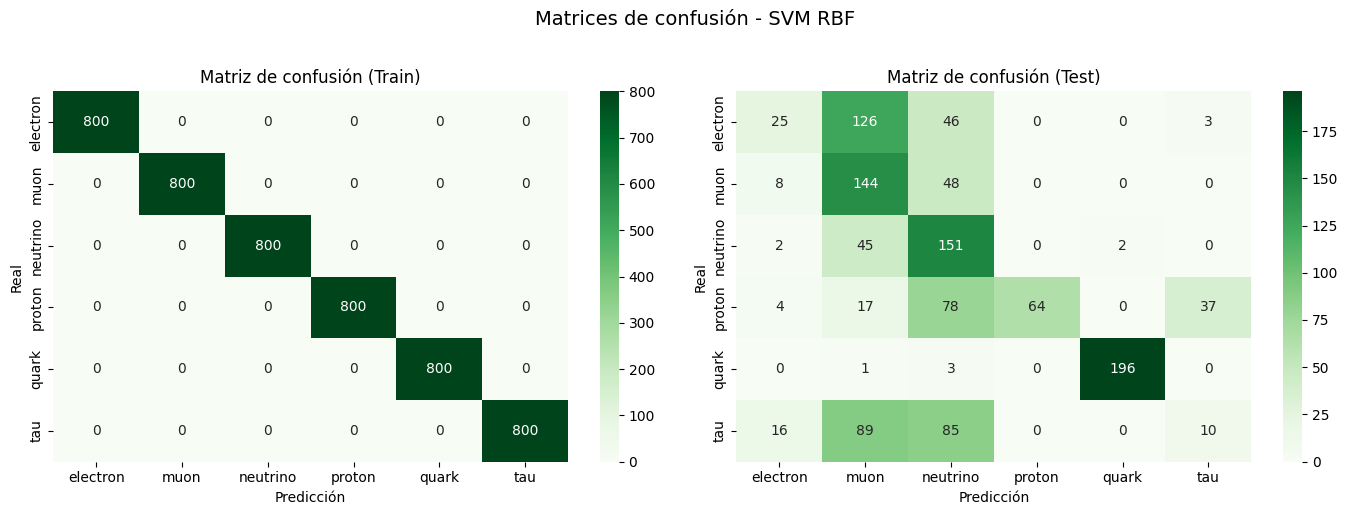

In [15]:
# Matriz de confusión - SVM RBF (Train y Test juntas)
cm_train_svm = confusion_matrix(y_train, y_train_pred_svm, labels=pipe_svm.classes_)
cm_test_svm = confusion_matrix(y_test, y_pred_svm, labels=pipe_svm.classes_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusión Train
sns.heatmap(cm_train_svm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=pipe_svm.classes_, yticklabels=pipe_svm.classes_, ax=axes[0])
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Real')
axes[0].set_title('Matriz de confusión (Train)')

# Matriz de confusión Test
sns.heatmap(cm_test_svm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=pipe_svm.classes_, yticklabels=pipe_svm.classes_, ax=axes[1])
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Real')
axes[1].set_title('Matriz de confusión (Test)')

plt.suptitle('Matrices de confusión - SVM RBF', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

#### 4.2.5 Curva de aprendizaje

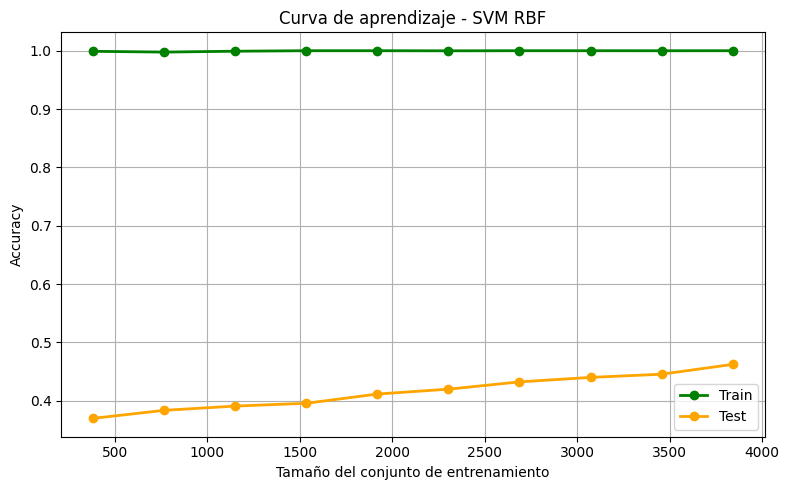

In [16]:
# Curva de aprendizaje - SVM RBF
train_sizes_svm, train_scores_svm, test_scores_svm = learning_curve(
    pipe_svm_cv, X_train, y_train, cv=5, 
    train_sizes=np.linspace(0.1, 1.0, 10), 
    scoring='accuracy'
)

train_mean_svm = train_scores_svm.mean(axis=1)
test_mean_svm = test_scores_svm.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes_svm, train_mean_svm, 'o-', label='Train', color='green', linewidth=2)
plt.plot(train_sizes_svm, test_mean_svm, 'o-', label='Test', color='orange', linewidth=2)
plt.xlabel('Tamaño del conjunto de entrenamiento')
plt.ylabel('Accuracy')
plt.title('Curva de aprendizaje - SVM RBF')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### 4.2.6 Curvas ROC-AUC

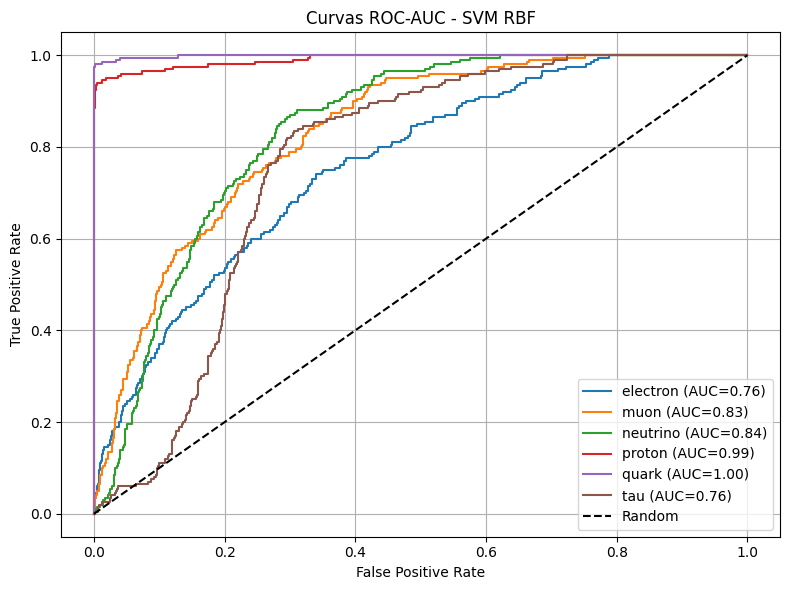

In [17]:
# Curvas ROC-AUC - SVM RBF
y_test_bin_svm = label_binarize(y_test, classes=pipe_svm.classes_)
y_score_svm = pipe_svm.predict_proba(X_test)

fpr_svm = dict()
tpr_svm = dict()
roc_auc_svm = dict()

for i in range(len(pipe_svm.classes_)):
    fpr_svm[i], tpr_svm[i], _ = roc_curve(y_test_bin_svm[:, i], y_score_svm[:, i])
    roc_auc_svm[i] = auc(fpr_svm[i], tpr_svm[i])

plt.figure(figsize=(8, 6))
for i, clase in enumerate(pipe_svm.classes_):
    plt.plot(fpr_svm[i], tpr_svm[i], label=f'{clase} (AUC={roc_auc_svm[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curvas ROC-AUC - SVM RBF')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

### MÉTRICAS PARA 500

Accuracy en train: 1.0000
Accuracy en test: 0.4333
Accuracy CV (5 folds): 0.4162

Reporte de clasificación:
              precision    recall  f1-score   support

    electron       0.31      0.17      0.22       100
        muon       0.34      0.56      0.42       100
    neutrino       0.31      0.80      0.45       100
      proton       1.00      0.06      0.11       100
       quark       0.98      0.99      0.99       100
         tau       0.14      0.02      0.04       100

    accuracy                           0.43       600
   macro avg       0.51      0.43      0.37       600
weighted avg       0.51      0.43      0.37       600

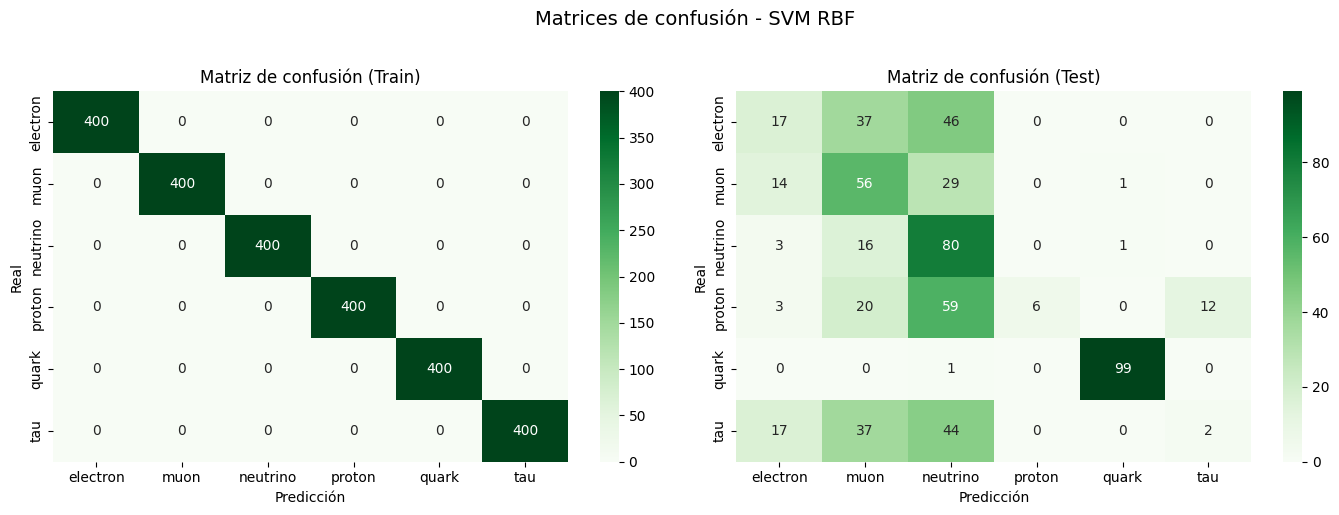

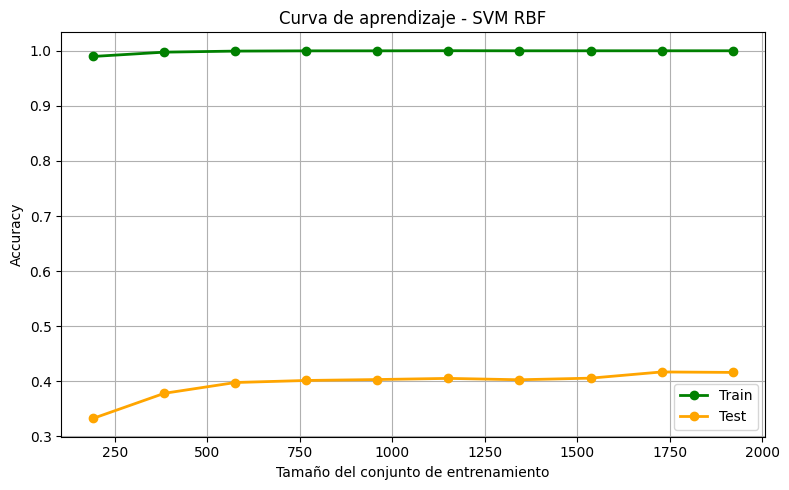

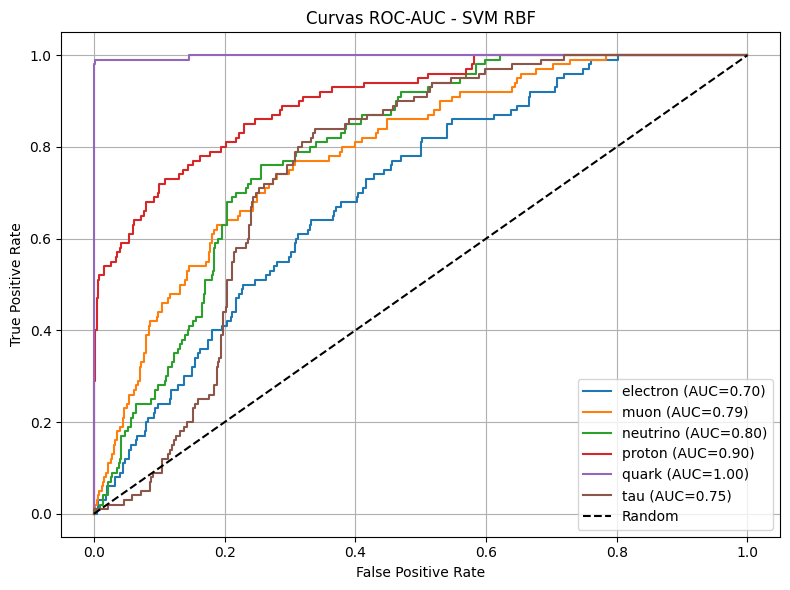